# Packages

In [1]:
import numpy as np
import pandas as pd #for loading csv Excel files
import itertools #to merge lists
from scipy import optimize as opt #for numerical root finding
from scipy.optimize import curve_fit
from scipy.optimize import fsolve, leastsq #for numerical root finding of a set of equations
from scipy.interpolate import interp1d
import scipy.integrate as integrate #for (numerical) integrating
import matplotlib.pyplot as pl #for plots
from matplotlib import rc, rcParams

#import emcee #for running MCMCs
import corner #for corner plots
from matplotlib.colors import LinearSegmentedColormap, colorConverter
from matplotlib.ticker import ScalarFormatter, NullFormatter
from scipy.ndimage import gaussian_filter
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes #for zoom-in boxes in plots
from mpl_toolkits.axes_grid1.inset_locator import mark_inset #for zoom-in boxes in plots

# Options for plotting

In [2]:
fontsize=26
legendfontsize=22
font = {'size' : fontsize}
rc('font',**font)
rc('text', usetex=True)
rc('font', family='serif', serif='Computer Modern Roman')

In [3]:
#Color palette accessible to colorblind people (see https://davidmathlogic.com/colorblind/)
lightblue='#1A85FF'
blue='#005AB5'
darkblue='#222255' #'#002E5D' #'#003A74' # #'#222255'
purple='#5D3A9B'
magenta='#AA4499'
darkmagenta='#8D2015' #'#882255'
pink='#CC6677' #'#CC79A7'
red='#DC3220'
orange='#E66100'
orangeSophia='#ff7f00'
yellow='#FFC20A'
green='#40B0A6'

colors=[lightblue,blue,darkblue,purple,magenta,darkmagenta,pink,red,orange,yellow,green]

In [4]:
goldenratio=1.61803398875 #Standard Python ratio for plot width/height=8/6.

# Constants

In [5]:
H0=70.*10.**(-3.) #km/s/kpc;
h=H0/(100.*10.**(-3.)) #for H0 in km/s/kpc

Omegam=0.3
OmegaL=0.7
G=4302./10.**9. #4.302*10^-6 kpc MSun^-1 (km/s)^2 

tage = 5.*10**9.*365.*24.*60.*60 #Assuming tage= 5 Gyr = 5*10^9*365*24*60*60 s
MSun_in_g = 1.98855*10.**30.*10.**3. #Msun in g
km_in_kpc = 1./(3.0857*10.**16.) #kpc=3.0857*10^16 km
cm_in_kpc = km_in_kpc/(10.**3.*10**2.)

### Plot median sigmavm vs. median v

In [42]:
xsctnmedianerrorsvals=np.load('xsctnmedianerrors_0p01_5_newnew.npy',allow_pickle=True)
print(xsctnmedianerrorsvals[0][0][0])
#sigmavmmedianerrorsvals=np.load('sigmavmmedianerrors_10_5000_newnew.npy',allow_pickle=True)
sigmavmmedianerrorsvals=np.load('sigmavmmedianerrors_10_10000_newnew.npy',allow_pickle=True)
velmedianerrorsvals=np.load('velmedianerrors_newnew.npy',allow_pickle=True)

[0.39204457 0.23313822 0.63140181 0.13795026 1.04238359 0.08069601
 1.87696508 0.87924634]


In [43]:
#[v,sigmavm]
sigmavm_v_dark_photon_model=np.loadtxt('C:/Users\Laura Sagunski/Laura Dropbox/Laura Sagunski/SIDM on Intermediate Scales/Notes/dark_photon_model_points.dat')
#print(sigmavm_v_dwarfs)

In [44]:
#[log10v,log10v_error,log10sigmavm,log10sigmavm_error]
logsigmavm_logv_dwarfs=np.loadtxt('C:/Users\Laura Sagunski/Laura Dropbox/Laura Sagunski/SIDM on Intermediate Scales/Notes/dwarf_points.dat')
print(logsigmavm_logv_dwarfs)
###Sort data from minimum to maximum velocity
ilogv_min_max=np.array([list(itertools.chain.from_iterable(np.argwhere(np.sort(logsigmavm_logv_dwarfs[:,0])[i]==logsigmavm_logv_dwarfs[:,0])))[0] for i in range(0,len(logsigmavm_logv_dwarfs[:,0]))])
logsigmavm_logv_dwarfs_sorted=np.array([logsigmavm_logv_dwarfs[i] for i in ilogv_min_max])
print(logsigmavm_logv_dwarfs_sorted)
#print(10**logsigmavm_logv_dwarfs_sorted)
#print(10**logsigmavm_logv_dwarfs_sorted[0][0],10.**logsigmavm_logv_dwarfs_sorted[0][1])

[[2.07468726 0.07242448 3.18208162 0.39034177]
 [1.81461965 0.03153385 2.3090429  0.35820987]
 [1.44702858 0.06572241 2.08720092 0.4700931 ]
 [1.67562362 0.07157076 1.15554382 0.42467868]
 [1.74520469 0.03701719 2.14172744 0.37367047]]
[[1.44702858 0.06572241 2.08720092 0.4700931 ]
 [1.67562362 0.07157076 1.15554382 0.42467868]
 [1.74520469 0.03701719 2.14172744 0.37367047]
 [1.81461965 0.03153385 2.3090429  0.35820987]
 [2.07468726 0.07242448 3.18208162 0.39034177]]


In [45]:
#[log10v,log10v_error,log10sigmavm,log10sigmavm_error]
logsigmavm_logv_LSBs=np.loadtxt('C:/Users\Laura Sagunski/Laura Dropbox/Laura Sagunski/SIDM on Intermediate Scales/Notes/LSB_points.dat')
print(logsigmavm_logv_LSBs)
###Sort data from minimum to maximum velocity
ilogv_min_max_LSBs=np.array([list(itertools.chain.from_iterable(np.argwhere(np.sort(logsigmavm_logv_LSBs[:,0])[i]==logsigmavm_logv_LSBs[:,0])))[0] for i in range(0,len(logsigmavm_logv_LSBs[:,0]))])
logsigmavm_logv_LSBs_sorted=np.array([logsigmavm_logv_LSBs[i] for i in ilogv_min_max_LSBs])
print(logsigmavm_logv_LSBs_sorted)
#print(10**logsigmavm_logv_LSBs_sorted)

[[2.2846917  0.0458708  1.84536785 0.34853206]
 [2.03157297 0.09819056 1.69646827 0.53024397]
 [2.13042924 0.03759328 2.02847268 0.3447598 ]
 [2.1241646  0.0365422  2.37694567 0.36150556]
 [2.04944251 0.07223366 3.15128748 0.35599865]
 [1.85049537 0.09459432 1.7242972  0.5014047 ]
 [2.03166011 0.02607692 2.45041278 0.32381974]]
[[1.85049537 0.09459432 1.7242972  0.5014047 ]
 [2.03157297 0.09819056 1.69646827 0.53024397]
 [2.03166011 0.02607692 2.45041278 0.32381974]
 [2.04944251 0.07223366 3.15128748 0.35599865]
 [2.1241646  0.0365422  2.37694567 0.36150556]
 [2.13042924 0.03759328 2.02847268 0.3447598 ]
 [2.2846917  0.0458708  1.84536785 0.34853206]]


In [46]:
#[log10v,log10v_error,log10sigmavm,log10sigmavm_error]
logsigmavm_logv_dwarfs_LSBs=np.array(list(itertools.chain.from_iterable([logsigmavm_logv_dwarfs,logsigmavm_logv_LSBs])))
print(logsigmavm_logv_dwarfs_LSBs)
###Sort data from minimum to maximum velocity
ilogv_min_max_dwarfs_LSBs=np.array([list(itertools.chain.from_iterable(np.argwhere(np.sort(logsigmavm_logv_dwarfs_LSBs[:,0])[i]==logsigmavm_logv_dwarfs_LSBs[:,0])))[0] for i in range(0,len(logsigmavm_logv_dwarfs_LSBs[:,0]))])
logsigmavm_logv_dwarfs_LSBs_sorted=np.array([logsigmavm_logv_dwarfs_LSBs[i] for i in ilogv_min_max_dwarfs_LSBs])
print(logsigmavm_logv_dwarfs_LSBs_sorted)
#print(10**logsigmavm_logv_dwarfs_LSBs_sorted)

[[2.07468726 0.07242448 3.18208162 0.39034177]
 [1.81461965 0.03153385 2.3090429  0.35820987]
 [1.44702858 0.06572241 2.08720092 0.4700931 ]
 [1.67562362 0.07157076 1.15554382 0.42467868]
 [1.74520469 0.03701719 2.14172744 0.37367047]
 [2.2846917  0.0458708  1.84536785 0.34853206]
 [2.03157297 0.09819056 1.69646827 0.53024397]
 [2.13042924 0.03759328 2.02847268 0.3447598 ]
 [2.1241646  0.0365422  2.37694567 0.36150556]
 [2.04944251 0.07223366 3.15128748 0.35599865]
 [1.85049537 0.09459432 1.7242972  0.5014047 ]
 [2.03166011 0.02607692 2.45041278 0.32381974]]
[[1.44702858 0.06572241 2.08720092 0.4700931 ]
 [1.67562362 0.07157076 1.15554382 0.42467868]
 [1.74520469 0.03701719 2.14172744 0.37367047]
 [1.81461965 0.03153385 2.3090429  0.35820987]
 [1.85049537 0.09459432 1.7242972  0.5014047 ]
 [2.03157297 0.09819056 1.69646827 0.53024397]
 [2.03166011 0.02607692 2.45041278 0.32381974]
 [2.04944251 0.07223366 3.15128748 0.35599865]
 [2.07468726 0.07242448 3.18208162 0.39034177]
 [2.1241646 

# Fit data with dark photon model 

# Data to fit

In [47]:
#_____Data points dwarfs+LSBs together_____
#[log10v,log10v_error,log10sigmavm,log10sigmavm_error]
#pl.plot(10.**logsigmavm_logv_dwarfs_sorted[:,0],10.**logsigmavm_logv_dwarfs_sorted[:,2],'.')
v_dwarfs_LSBs=10.**logsigmavm_logv_dwarfs_LSBs_sorted[:,0]
v_lower_dwarfs_LSBs=10.**(logsigmavm_logv_dwarfs_LSBs_sorted[:,0]-logsigmavm_logv_dwarfs_LSBs_sorted[:,1])
v_upper_dwarfs_LSBs=10.**(logsigmavm_logv_dwarfs_LSBs_sorted[:,0]+logsigmavm_logv_dwarfs_LSBs_sorted[:,1])
sigmavm_dwarfs_LSBs=10.**logsigmavm_logv_dwarfs_LSBs_sorted[:,2]
sigmavm_lower_dwarfs_LSBs=10.**(logsigmavm_logv_dwarfs_LSBs_sorted[:,2]-logsigmavm_logv_dwarfs_LSBs_sorted[:,3])
sigmavm_upper_dwarfs_LSBs=10.**(logsigmavm_logv_dwarfs_LSBs_sorted[:,2]+logsigmavm_logv_dwarfs_LSBs_sorted[:,3])

In [48]:
xsctn_dwarfs_LSBs=sigmavm_dwarfs_LSBs/v_dwarfs_LSBs
print(xsctn_dwarfs_LSBs)
xsctn_lower_dwarfs_LSBs=sigmavm_lower_dwarfs_LSBs/v_dwarfs_LSBs
print(xsctn_lower_dwarfs_LSBs)
xsctn_upper_dwarfs_LSBs=sigmavm_upper_dwarfs_LSBs/v_dwarfs_LSBs
print(xsctn_upper_dwarfs_LSBs)

[ 4.36689086  0.30193968  2.49185493  3.12193064  0.74782819  0.46226956
  2.62272447 12.64284953 12.80543555  1.78970343  0.79075772  0.36364377]
[1.47937827 0.11356422 1.05402835 1.36840101 0.23572038 0.1363488
 1.24432243 5.5698862  5.21257817 0.77853028 0.35750625 0.16298367]
[12.89037166  0.80278431  5.89105694  7.12251079  2.37250171  1.56725358
  5.52805563 28.69747039 31.45836367  4.11421168  1.74905407  0.81134994]


In [49]:
#_____Data points groups+cluster (only pure SIDM, no AC for fit)_____

In [50]:
j=0 #parspace=['Sean']

xsctn_groups_clusters=[]
xsctn_lower_groups_clusters=[]
xsctn_upper_groups_clusters=[]

sigmavm_groups_clusters=[]
sigmavm_lower_groups_clusters=[]
sigmavm_upper_groups_clusters=[]

v_groups_clusters=[]
v_lower_groups_clusters=[]
v_upper_groups_clusters=[]

for i in [0,1]: #i=['groupsdata','clustersdata']
    if i==0:
        k=1 #case: k=[GradNoGrad,DMprofile]=[['Grad','NFW'],['ScanGrad','NFW'],['ScanGrad','GnMod']] for groups.
    elif i==1:
        k=0 #case: k=[MLerr,DMprofile]=[['03','NFW'],['03','GnMod']] for clusters.
    [medianxsctn,lowererror68xsctn,uppererror68xsctn,lowererror95xsctn,uppererror95xsctn,lowererror99p7xsctn,uppererror99p7xsctn,upperbound95vel]=xsctnmedianerrorsvals[i][j][k]
    [mediansigmavm,lowererror68sigmavm,uppererror68sigmavm,lowererror95sigmavm,uppererror95sigmavm,lowererror99p7sigmavm,uppererror99p7sigmavm,upperbound95sigmavm]=sigmavmmedianerrorsvals[i][j][k]
    [medianvel,lowererror68vel,uppererror68vel,lowererror95vel,uppererror95vel,lowererror99p7vel,uppererror99p7vel,upperbound95vel]=velmedianerrorsvals[i][j][k]
    
    xsctn_groups_clusters_vals=medianxsctn
    xsctn_lower_groups_clusters_vals=lowererror68xsctn
    xsctn_upper_groups_clusters_vals=uppererror68xsctn
    
    xsctn_groups_clusters.append(xsctn_groups_clusters_vals)
    xsctn_lower_groups_clusters.append(xsctn_lower_groups_clusters_vals)
    xsctn_upper_groups_clusters.append(xsctn_upper_groups_clusters_vals)
    
    sigmavm_groups_clusters_vals=mediansigmavm
    sigmavm_lower_groups_clusters_vals=lowererror68sigmavm
    sigmavm_upper_groups_clusters_vals=uppererror68sigmavm
    
    sigmavm_groups_clusters.append(sigmavm_groups_clusters_vals)
    sigmavm_lower_groups_clusters.append(sigmavm_lower_groups_clusters_vals)
    sigmavm_upper_groups_clusters.append(sigmavm_upper_groups_clusters_vals)
    
    v_groups_clusters_vals=medianvel
    v_lower_groups_clusters_vals=lowererror68vel
    v_upper_groups_clusters_vals=uppererror68vel
    
    v_groups_clusters.append(v_groups_clusters_vals)
    v_lower_groups_clusters.append(v_lower_groups_clusters_vals)
    v_upper_groups_clusters.append(v_upper_groups_clusters_vals)
    
xsctn_groups_clusters=np.array(xsctn_groups_clusters)
print(xsctn_groups_clusters)
xsctn_lower_groups_clusters=np.array(xsctn_lower_groups_clusters)
print(xsctn_lower_groups_clusters)
xsctn_upper_groups_clusters=np.array(xsctn_upper_groups_clusters)
print(xsctn_upper_groups_clusters)

sigmavm_groups_clusters=np.array(sigmavm_groups_clusters)
print(sigmavm_groups_clusters)
sigmavm_lower_groups_clusters=np.array(sigmavm_lower_groups_clusters)
print(sigmavm_lower_groups_clusters)
sigmavm_upper_groups_clusters=np.array(sigmavm_upper_groups_clusters)
print(sigmavm_upper_groups_clusters)

v_groups_clusters=np.array(v_groups_clusters)
print(v_groups_clusters)
v_lower_groups_clusters=np.array(v_lower_groups_clusters)
print(v_lower_groups_clusters)
v_upper_groups_clusters=np.array(v_upper_groups_clusters)
print(v_upper_groups_clusters)

print(sigmavm_groups_clusters)
print(xsctn_groups_clusters*v_groups_clusters)

[0.37780536 0.15381854]
[0.21397591 0.10757993]
[0.61917803 0.22090639]
[338.13314579 226.48550461]
[163.05695908 136.41935556]
[638.94008552 357.64187309]
[1152.85558261 1914.4825665 ]
[1118.25001193 1789.29006552]
[1198.99828832 2032.58434785]
[338.13314579 226.48550461]
[435.55501429 294.4829099 ]


In [51]:
xsctn_fit=list(itertools.chain.from_iterable([xsctn_dwarfs_LSBs,xsctn_groups_clusters]))
print(xsctn_fit)
xsctn_lower_fit=list(itertools.chain.from_iterable([xsctn_lower_dwarfs_LSBs,xsctn_lower_groups_clusters]))
#print(xsctn_lower_fit)
xsctn_upper_fit=list(itertools.chain.from_iterable([xsctn_upper_dwarfs_LSBs,xsctn_upper_groups_clusters]))
#print(xsctn_upper_fit)

sigmavm_fit=list(itertools.chain.from_iterable([sigmavm_dwarfs_LSBs,sigmavm_groups_clusters]))
print(sigmavm_fit)
sigmavm_lower_fit=list(itertools.chain.from_iterable([sigmavm_lower_dwarfs_LSBs,sigmavm_lower_groups_clusters]))
#print(sigmavm_lower_fit)
sigmavm_upper_fit=list(itertools.chain.from_iterable([sigmavm_upper_dwarfs_LSBs,sigmavm_upper_groups_clusters]))
#print(sigmavm_upper_fit)

v_fit=list(itertools.chain.from_iterable([v_dwarfs_LSBs,v_groups_clusters]))
#print(v_fit)
v_lower_fit=list(itertools.chain.from_iterable([v_lower_dwarfs_LSBs,v_lower_groups_clusters]))
#print(v_lower_fit)
v_upper_fit=list(itertools.chain.from_iterable([v_upper_dwarfs_LSBs,v_upper_groups_clusters]))
#print(v_upper_fit)

[4.366890859638267, 0.30193968172527486, 2.4918549317290335, 3.1219306447035815, 0.7478281922448595, 0.4622695642494, 2.6227244667716687, 12.642849529937024, 12.805435550664965, 1.7897034331785433, 0.7907577183272417, 0.36364376782337854, 0.377805356421525, 0.15381853825817188]
[122.23650378473026, 14.306843183659097, 138.58857889183093, 203.72432945204253, 53.00260351231528, 49.71280567646726, 282.10629709657684, 1416.7312839172537, 1520.8333083935775, 238.202144306341, 106.77576093297537, 70.04350180982932, 338.13314579438935, 226.48550461024263]


## Constants

In [52]:
c=2.99792458*10.**8.*10.**(-3.) #km/s (not m/s)
GeV_to_cmminus1=5.068*10.**13.
GeV_to_g=1.78*10.**(-24.)
fm_to_cm=10.**(-15.)*10.**2.

## Data dark photon model

In [53]:
potentials=['attractive','repulsive'] 
#datadarkphotonmodel=np.array([pd.read_csv('DataDarkPhotonModel/crosssec_'+str(potential)+'.csv',header=-1).values for potential in potentials]) #header=-1 needed to load da a from first line.
datadarkphotonmodel=np.array([pd.read_csv('C:/Users/Laura Sagunski/Laura Dropbox (1)/Laura Sagunski/Self-interaction cross section/DataDarkPhotonModel/crosssec_'+str(potential)+'.csv',header=None).values for potential in potentials]) #header=-1 needed to load da a from first line.
avals=np.array(datadarkphotonmodel[0][:,0]) #Same avals for both potentials.
#print(avals) 
uniqueavals=np.unique(avals)
#print(uniqueavals)
bvals=np.array(datadarkphotonmodel[0][:,1]) #Same bvals for both potentials.
#print(bvals) 
uniquebvals=np.unique(bvals)
#print(uniquebvals)
print(len(uniquebvals))
cvals=[datadarkphotonmodel[i][:,2] for i in range(0,len(datadarkphotonmodel))]
#print(cvals) 

1001


## Generate 2D interpolation function c(a,b)

In [54]:
#_____Extract lines in data dark photon model with same bvals (repeat each other)_____
ibvals=np.array([list(itertools.chain.from_iterable(np.argwhere(bvals==uniquebvals[i]))) for i in range(0,len(uniquebvals))])
#print(ibvals[0])
#_____For fixed b interpolate in terms of a: c(a)_____
###Note: Small, negligible differences between linear and cubic interpolation function. Interpolation function might break down when extrapolating to values far outside the range of [a,b]. 
#caint=np.array([[interp1d([avals[k] for k in ibvals[j]],[cvals[i][k] for k in ibvals[j]],kind='linear') for j in range(0,len(ibvals))] for i in range(0,len(potentials))])
caint=np.array([[interp1d([avals[k] for k in ibvals[j]],[cvals[i][k] for k in ibvals[j]],kind='cubic',fill_value='extrapolate') for j in range(0,len(ibvals))] for i in range(0,len(potentials))])
#print(caint)

In [55]:
#_____2D interpolation function c(a,b)_____
def cab(potential,a,b):
    if potential=='attractive':
        caInt=caint[0]
    elif potential=='repulsive':
        caInt=caint[1]
    #_____Evaluate all interpolation functions c(b) at b and interpolate in terms of a: c(a,b)_____
    cavals=[caInt[i](a) for i in range(0,len(caInt))]
    cab=interp1d(uniquebvals,cavals,kind='cubic',fill_value='extrapolate')(b) #,kind='cubic',fill_value='extrapolate'
    return cab
    
for potential in ['attractive']: #['attractive','repulsive']:
    for b in [0.1]: #[0.1,10.,100.,1000.,10000.]
        for a in [avals[0],avals[1],10**(-10.)]:
            print([a,b,cab(potential,a,b)])

[1e-05, 0.1, array(1.10814e-14)]
[1.05925e-05, 0.1, array(1.24335e-14)]
[1e-10, 0.1, array(-5.79385703e-16)]


## sigmaT(v)

In [56]:
def sigmaT(potential,alphaX,mX,mphi,v):
    a=(1/(2.*alphaX))*(v/c) #Divide by c to make a dimensionless. Ok.
    b=alphaX*(mX/mphi)
    #print('[a,b]='+str([a,b]))
    sigmaT=(16.*np.pi*cab(potential,a,b))/((mX*GeV_to_cmminus1)**2.*(v**2/c**2.)) #cm**2
    return sigmaT

def sigmaT_over_m(potential,alphaX,mX,mphi,v):
    sigmaT_over_m=sigmaT(potential,alphaX,mX,mphi,v)/(mX*GeV_to_g) #cm**2/g
    return sigmaT_over_m

def sigmaT_times_m2(potential,alphaX,mX,mphi,v):
    sigmaT_times_m2=sigmaT_over_m(potential,alphaX,mX,mphi,v)*mX**3. #cm**2/g*GeV**3.
    return sigmaT_times_m2

for potential in ['repulsive']: #['attractive','repulsive']:
    for alphaX in [10.**(-2.)]:
        for mX in [200]: #GeV
            for mphi in [10**(-3.)]: #GeV.
                for v in [1000]: #km/s
                    print('sigmaT [cm^2]='+str(sigmaT(potential,alphaX,mX,mphi,v)))
                    print('sigmaT/m [cm^2/g]='+str(sigmaT_over_m(potential,alphaX,mX,mphi,v)))
                    print('sigmaT*m [(cm^2/g) GeV^3]='+str(sigmaT_times_m2(potential,alphaX,mX,mphi,v)))

sigmaT [cm^2]=-4.766672998733928e-21
sigmaT/m [cm^2/g]=-13.389530895320023
sigmaT*m [(cm^2/g) GeV^3]=-107116247.16256018


## Velocity-averaged cross section

In [57]:
#_____Maxwell-Boltzmann distribution_____
#def f(v,v0,vmax):
def f(v,v0):
    f=(4*v**2.*np.exp(-(v**2./v0**2)))/(np.sqrt(np.pi)*v0**3.) #*np.heaviside(vmax-v,0.)
    return f

for v in [10**3]:
    for v0 in [10**2.]:
        #for vmax in [10**5]:
        #print(f(v,v0,vmax))
        print(f(v,v0))

8.395312462708834e-44


In [58]:
#_____Velocity-averaged cross section_____
#def xsctnav(potential,alphaX,mX,mphi,vav,vmax):
def xsctnav(potential,alphaX,mX,mphi,vav):
    v0=(np.sqrt(np.pi)/2.)*vav
    def integrand_sigmavmav(v):
        #return f(v,v0,vmax)*sigmaT_over_m(potential,alphaX,mX,mphi,v)*v
        return f(v,v0)*sigmaT_over_m(potential,alphaX,mX,mphi,v)*v
    vintegrationmin=10**(-2.)*v0 #Lower limit can be as large as this. Resut for integral doesn't change significantly.
    vintegrationmax=10**(2.)*v0#vmax #10.**50. #np.inf
    #print([sigmaT_over_m(potential,alphaX,mX,mphi,v0),integrand_sigmavmav(v0)])
    #print([f(vintegrationmin,v0),f(vintegrationmax,v0)])
    sigmavmav=integrate.quad(integrand_sigmavmav,vintegrationmin,vintegrationmax,points=v0,limit=200)[0]
    xsctnav=sigmavmav/vav
    return xsctnav

# for potential in ['repulsive']: #['attractive','repulsive']:
#     for alphaX in [1./137.]:
#         for mX in [7.7]: #GeV
#             for mphi in [0.01]: #GeV.
#                 for vav in [10.**5.]:
#                     #for vmax in [10.**6.]:
#                     #print(xsctnav(potential,alphaX,mX,mphi,vav,vmax))
#                     print(xsctnav(potential,alphaX,mX,mphi,vav))

In [59]:
#_____Velocity-averaged cross section_____
#def xsctnav(potential,alphaX,mX,mphi,vav,vmax):
def sigmavmav(potential,alphaX,mX,mphi,vav):
    v0=(np.sqrt(np.pi)/2.)*vav
    def integrand_sigmavmav(v):
        #return f(v,v0,vmax)*sigmaT_over_m(potential,alphaX,mX,mphi,v)*v
        return f(v,v0)*sigmaT_over_m(potential,alphaX,mX,mphi,v)*v
    vintegrationmin=10**(-2.)*v0 #Lower limit can be as large as this. Resut for integral doesn't change significantly.
    vintegrationmax=10**(2.)*v0#vmax #10.**50. #np.inf
    #print([sigmaT_over_m(potential,alphaX,mX,mphi,v0),integrand_sigmavmav(v0)])
    #print([f(vintegrationmin,v0),f(vintegrationmax,v0)])
    sigmavmav=integrate.quad(integrand_sigmavmav,vintegrationmin,vintegrationmax,points=v0,limit=200)[0]
    #xsctnav=sigmavmav/vav
    #return xsctnav
    return sigmavmav

# for potential in ['repulsive']: #['attractive','repulsive']:
#     for alphaX in [1./137.]:
#         for mX in [7.7]: #GeV
#             for mphi in [0.01]: #GeV.
#                 for vav in [10.**5.]:
#                     #for vmax in [10.**6.]:
#                     #print(xsctnav(potential,alphaX,mX,mphi,vav,vmax))
#                     print(sigmavmav(potential,alphaX,mX,mphi,vav))

## Fit function

In [62]:
def xsctn_fitfunction(vvals,mX,mphi):
    potential='repulsive'
    alphaX=1./137.
    #vmax=10.**6.
    #output=np.array(np.array([xsctnav(potential,alphaX,mX,mphi,v,vmax) for v in vvals]))
    output=np.array(np.array([xsctnav(potential,alphaX,mX,mphi,v) for v in vvals]))
    return output

# for mX in [15.]:
#     for mphi in [17.*10**(-3.)]:
#         print(xsctn_fitfunction(v_groups_clusters,mX,mphi))

In [63]:
def sigmavm_fitfunction(vvals,mX,mphi):
    potential='repulsive'
    alphaX=1./137.
    #vmax=10.**6.
    #output=np.array(np.array([xsctnav(potential,alphaX,mX,mphi,v,vmax) for v in vvals]))
    output=np.array(np.array([sigmavmav(potential,alphaX,mX,mphi,v) for v in vvals]))
    return output

# for mX in [15.]:
#     for mphi in [17.*10**(-3.)]:
#         print(xsctn_fitfunction(v_groups_clusters,mX,mphi))

In [68]:
#mXmphi_bestfitvals=np.load('mXmphi_bestfitvals.npy')
mXmphi_bestfitvals=np.load('mXmphi_bestfitvals_newnew.npy')
print(mXmphi_bestfitvals)
#mXmphi_sigmavm_bestfitvals=np.load('mXmphi_sigmavm_bestfitvals_newnew.npy')
mXmphi_sigmavm_bestfitvals=np.load('mXmphi_sigmavm_bestfitvals_10_10000_newnew.npy')
print(mXmphi_sigmavm_bestfitvals)

[10.89993205  0.01477216]
[12.12143552  0.01566567]


In [71]:
#mXmphi_bestfitvals=np.load('mXmphi_bestfitvals.npy')
mXmphi_bestfitvals_takeawayvalues=np.load('mXmphi_bestfitvals_takeawayvalues.npy')
print(mXmphi_bestfitvals_takeawayvalues)
#mXmphi_sigmavm_bestfitvals=np.load('mXmphi_sigmavm_bestfitvals_newnew.npy')
mXmphi_sigmavm_10_10000_takeawayvalues=np.load('mXmphi_bestfitvals_sigmavm_10_10000_takeawayvalues.npy')
print(mXmphi_sigmavm_10_10000_takeawayvalues)

[1.31657675e+01 9.46338382e-03]
[1.75045857e+01 6.15092062e-03]


In [73]:
xsctn_bestfitvals_takeawayvalues=np.load('xsctn_bestfitvals_takeawayvalues.npy')
#print(xsctn_bestfitvals)

sigmavm_bestfitvals_takeawayvalues=np.load('sigmavm_bestfitvals_takeawayvalues.npy')
#print(sigmavm_bestfitvals)

In [76]:
vvals=np.logspace(np.log10(10.),np.log10(5000.),100)

In [78]:
xsctn_bestfitvals_rounded=np.load('xsctn_bestfitvals_rounded_newnew.npy')
print(xsctn_bestfitvals_rounded)

#sigmavm_bestfitvals_rounded=np.load('sigmavm_bestfitvals_rounded_newnew.npy')
#sigmavm_bestfitvals_rounded=np.load('sigmavm_bestfitvals_rounded_newnew.npy')
sigmavm_bestfitvals_rounded=np.load('sigmavm_bestfitvals_10_10000_rounded_newnew.npy')
print(sigmavm_bestfitvals_rounded)

[3.2638536  3.26317249 3.26240187 3.26152996 3.26054352 3.2594277
 3.25816553 3.2567387  3.2551255  3.25330195 3.25124151 3.24891403
 3.24628577 3.24331903 3.23997161 3.23619648 3.2319412  3.22714746
 3.22175045 3.21567809 3.20885048 3.20117902 3.19256609 3.18290479
 3.17207901 3.15996388 3.1464261  3.13132469 3.11451167 3.09583287
 3.07512911 3.05223754 3.02699382 2.99923435 2.96879947 2.93553754
 2.89930644 2.85998344 2.81746479 2.77167277 2.72255937 2.67010924
 2.6143417  2.55531197 2.49311158 2.42786877 2.35974846 2.2889516
 2.21571446 2.14030603 2.06302479 1.98419404 1.90415613 1.82326597
 1.74188414 1.66037007 1.57907556 1.4983391  1.41848109 1.33980017
 1.26257069 1.1870412  1.11343376 1.04194397 0.97274143 0.90597044
 0.84175096 0.78017963 0.72133088 0.66525806 0.61199464 0.56155543
 0.51393777 0.46912281 0.42707674 0.38775207 0.35108885 0.31701601
 0.28545255 0.25630884 0.2294879  0.20488658 0.18239686 0.161907
 0.14330275 0.12646845 0.11128815 0.09764659 0.08543017 0.07452777

In [83]:
#_____Data points groups+clusters_____
for i in [0,1,2]: #i=['groupsdata','clustersdata','simsdata']
    if i==0: #'groupsdata'
        Names=names
        #title='Groups, \,\,'
        title='Groups'
        colors=[blue,blue,blue,blue,darkblue,darkblue,purple,green,orange,yellow]
        linewidths=[3,3,1.5]
        
        jvals=[0] #parspace=['Sean','Python code, M200csigmavm+M200cCDM','Python code, rho0sigma0sigmavm']
        kvals=[1,2] #case: k=[GradNoGrad,DMprofile]=[['Grad','NFW'],['ScanGrad','NFW'],['ScanGrad','GnMod']] for groups, k=[MLerr,DMprofile]=[['01','NFW'],['03','NFW']] for clusters.
        lvals=range(0,len(names))
        
    elif i==1: #'clustersdata'
        Names=namesclusters
        #title='Clusters, '
        title='Clusters'
        colors=[red,red,magenta]
        linewidths=[3,1.5]
        
        jvals=[0] #parspace='Sean'
        kvals=[0,1] #case: k=[MLerr,DMprofile]=[['03','NFW'],['03','GnMod']] for clusters.
        lvals=range(0,len(namesclusters))
        
    elif i==2: #'simssdata'
        jvals=[0] #parspace='Sean'
        Names=namessims
        #title='Simulations, '
        title='Simulations'
        #title='Sim., '
        colors=['gray','gray','gray','darkgray','lightgray']
        linewidths=[3,1.5]
        jvals=[0] #parspace='Sean'
        kvals=[0,1,2] #case: k=[parspace,DMprofile,PA]=[['M200csigmavm','NFW','PA0'],['M200csigmavm','NFW','PA45'],['M200csigmavm','NFW','PA90']] for sims  
        lvals=range(0,len(namessims))
    
    print(title)

    for j in jvals: #parspace: j=['Sean']
        for k in kvals: #case: k=[GradNoGrad,DMprofile]=[['Grad','NFW'],['ScanGrad','NFW'],['ScanGrad','GnMod']] for groups, k=[MLerr,DMprofile]=[['01','NFW'],['03','NFW']] for clusters.
            
            [medianxsctn,lowererror68xsctn,uppererror68xsctn,lowererror95xsctn,uppererror95xsctn,lowererror99p7xsctn,uppererror99p7xsctn,upperbound95xstcn]=xsctnmedianerrorsvals[i][j][k]
            [medianvel,lowererror68vel,uppererror68vel,lowererror95vel,uppererror95vel,lowererror99p7vel,uppererror99p7vel,upperbound95vel]=velmedianerrorsvals[i][j][k]
            mediansigmavm=medianxsctn*medianvel
            print('[v,sigma*v/m,sigmavm]')
            print([medianvel,mediansigmavm,sigmavmmedianerrorsvals[i][j][k][0]])
            print('')

Groups
[v,sigma*v/m,sigmavm]
[1152.8555826134125, 435.5550142918052, 338.13314579438935]

[v,sigma*v/m,sigmavm]
[1152.2620495023843, 669.8090240168771, 680.7045947727453]

Clusters
[v,sigma*v/m,sigmavm]
[1914.4825665045162, 294.48290990047803, 226.48550461024263]

[v,sigma*v/m,sigmavm]
[1894.3853221146228, 374.10297259999413, 319.45390625450796]

Simulations
[v,sigma*v/m,sigmavm]
[1141.7490644873153, 1267.6162709559997, 1041.6531516113976]

[v,sigma*v/m,sigmavm]
[1113.6627755017753, 1836.8910606363022, 1572.4280924262464]

[v,sigma*v/m,sigmavm]
[1112.7847931342885, 1610.1242457463782, 1431.5633584958389]



## Plot

[1152.2620495023843, 1111.0102043253887, 1209.343048553232]
[1152.8555826134125, 1118.2500119324868, 1198.9982883214461]
[1894.3853221146228, 1768.4066737693977, 2025.8852852241168]
[1914.4825665045162, 1789.2900655240428, 2032.584347845865]
[1112.7847931342885, 1097.0095754635604, 1133.4915043411663]
[1113.6627755017753, 1096.634726809741, 1142.1995630464198]
[1141.7490644873153, 1102.1353921580271, 1180.8616476341738]
Plots/directsigmavm_vs_v_SIDM_groups_clusters.pdf exported.


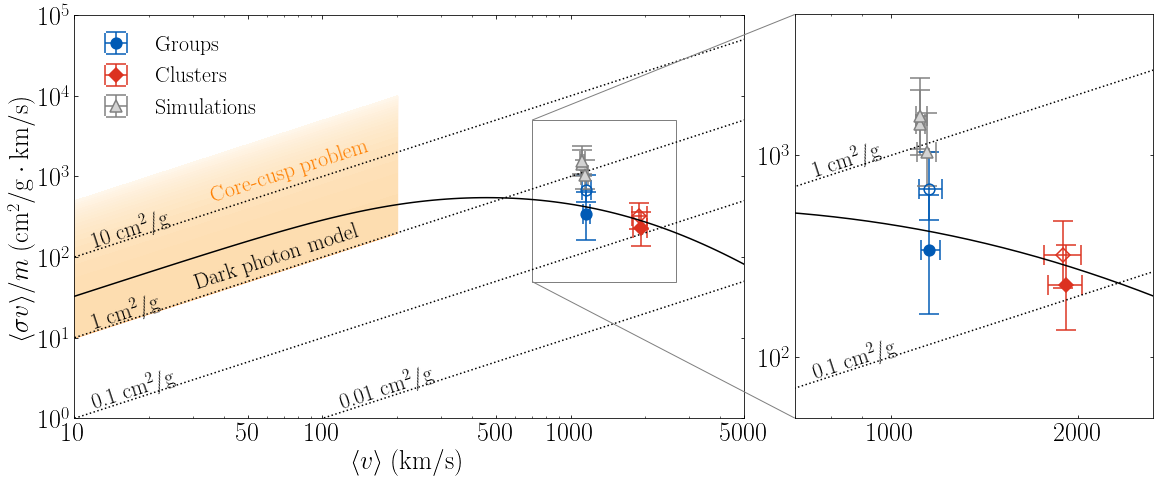

In [143]:
#integrationlimitsplots=[0.,1.5.] #Lower integration limit cannot be 0 here because of logspacing for xsctnvalsInt (np.log(0)=-np.inf).
integrationlimitsplots=[10**-3.,1.5]
[xsctnmin,xsctnmax]=[0.,integrationlimitsplots[1]]
marker='.'
markersize=15

#pl.figure(figsize=(goldenratio*6,6))
#pl.figure(figsize=(12,12/goldenratio)) #Sophia's plot size.
fig, ax = pl.subplots(figsize=(12,12/goldenratio))
axins = zoomed_inset_axes(ax,2.5,loc='upper right',bbox_to_anchor=(1200.,483.62)) # zoom-factor: 2.5, location: upper-left
#_____Data points groups+clusters_____
for i in [0,1,2]: #i=['groupsdata','clustersdata','simsdata']
#for i in [2,1,0]: #i=['groupsdata','clustersdata','simsdata']
    if i==0: #'groupsdata'
        Names=names
        #title='Groups, \,\,'
        title='Groups'
        colors=[blue,blue,blue,blue,darkblue,darkblue,purple,green,orange,yellow]
        linewidths=[3,3,1.5]
        
        jvals=[0] #parspace=['Sean','Python code, M200csigmavm+M200cCDM','Python code, rho0sigma0sigmavm']
        kvals=[1,2][::-1] #case: k=[GradNoGrad,DMprofile]=[['Grad','NFW'],['ScanGrad','NFW'],['ScanGrad','GnMod']] for groups, k=[MLerr,DMprofile]=[['01','NFW'],['03','NFW']] for clusters.
        lvals=range(0,len(names))
        
    elif i==1: #'clustersdata'
        Names=namesclusters
        #title='Clusters, '
        title='Clusters'
        colors=[red,red,magenta]
        linewidths=[3,1.5]
        
        jvals=[0] #parspace='Sean'
        kvals=[0,1][::-1] #case: k=[MLerr,DMprofile]=[['03','NFW'],['03','GnMod']] for clusters.
        lvals=range(0,len(namesclusters))
        
    elif i==2: #'simssdata'
        jvals=[0] #parspace='Sean'
        Names=namessims
        #title='Simulations, '
        title='Simulations'
        #title='Sim., '
        #colors=['gray','gray','gray','darkgray','lightgray']
        colors=['lightgray','lightgray','lightgray','lightgray','lightgray']
        markeredgecolor='gray'
        linewidths=[3,1.5]
        
        jvals=[0] #parspace='Sean'
        kvals=[0,1,2][::-1] #case: k=[parspace,DMprofile,PA]=[['M200csigmavm','NFW','PA0'],['M200csigmavm','NFW','PA45'],['M200csigmavm','NFW','PA90']] for sims  
        lvals=range(0,len(namessims))


    for j in jvals: #parspace: j=['Sean']
        for k in kvals: #case: k=[GradNoGrad,DMprofile]=[['Grad','NFW'],['ScanGrad','NFW'],['ScanGrad','GnMod']] for groups, k=[MLerr,DMprofile]=[['01','NFW'],['03','NFW']] for clusters.
            if i==0 and k==1:
                fillstyle='full'
                marker='.'
                markersize=21.5
            #elif k==1:
            elif i==0 and k==2:
                fillstyle='none'
                marker='.'
                markersize=21.5
            
            elif i==1 and k==0: #case: k=[MLerr,DMprofile]=[['03','NFW'],['03','GnMod']] for clusters.
                fillstyle='full'
                marker='D'
                markersize=10
            elif i==1 and k==1: 
                fillstyle='none'
                marker='D'
                markersize=10
           
            elif i==2 and k==0: #case: k=[parspace,DMprofile,PA]=[['M200csigmavm','NFW','PA0'],['M200csigmavm','NFW','PA45'],['M200csigmavm','NFW','PA90']] for sims  
                fillstyle='full'
                marker='^'
                markersize=12.5
            elif i==2 and k==1:
                fillstyle='full'
                marker='^'
                markersize=12.5
            elif i==2 and k==2:
                fillstyle='full'
                marker='^'
                markersize=12.5

            #[label,name,chain]=chains(i,j,k,0) #Needed here to get right label.
            [medianxsctn,lowererror68xsctn,uppererror68xsctn,lowererror95xsctn,uppererror95xsctn,lowererror99p7xsctn,uppererror99p7xsctn,upperbound95xsctn]=xsctnmedianerrorsvals[i][j][k]
            [medianvel,lowererror68vel,uppererror68vel,lowererror95vel,uppererror95vel,lowererror99p7vel,uppererror99p7vel,upperbound95vel]=velmedianerrorsvals[i][j][k]
            mediansigmavm=medianxsctn*medianvel
            #print(mediansigmavm)
            print([medianvel,lowererror68vel,uppererror68vel])
            #lowererrorsigmavm=np.sqrt((medianvel*lowererrorxsctn)**2.+(medianxsctn*lowererrorvel)**2.)
            #uppererrorsigmavm=np.sqrt((medianvel*uppererrorxsctn)**2.+(medianxsctn*uppererrorvel)**2.)
            lowererror68sigmavm=medianvel*lowererror68xsctn #Only take value of cross section into account here.
            uppererror68sigmavm=medianvel*uppererror68xsctn
            
            [directmediansigmavm,directlowererror68sigmavm,directuppererror68sigmavm,directlowererror95sigmavm,directuppererror95sigmavm,directlowererror99p7sigmavm,directuppererror99p7sigmavm,directupperbound95sigmavm]=sigmavmmedianerrorsvals[i][j][k]
            if i==2: #Dark outlines for simulation markerpoints
                if k==kvals[-1]:
                    #pl.errorbar(medianvel,mediansigmavm,xerr=[[medianvel-lowererror68vel],[uppererror68vel-medianvel]],yerr=[[mediansigmavm-lowererror68sigmavm],[uppererror68sigmavm-mediansigmavm]],fmt=marker,markersize=markersize,color=colors[k],fillstyle=fillstyle,solid_capstyle='projecting',lw=1.5,capthick=1.5,capsize=10,label=title) #,label=title+label
                    ax.errorbar(medianvel,directmediansigmavm,xerr=[[medianvel-lowererror68vel],[uppererror68vel-medianvel]],yerr=[[directmediansigmavm-directlowererror68sigmavm],[directuppererror68sigmavm-directmediansigmavm]],fmt=marker,markersize=markersize,color=colors[k],fillstyle=fillstyle,solid_capstyle='projecting',lw=1.5,capthick=1.5,capsize=10,markeredgewidth=1.5, markeredgecolor=markeredgecolor,ecolor=markeredgecolor,label=title) #,label=title+label
                else:
                    #pl.errorbar(medianvel,mediansigmavm,xerr=[[medianvel-lowererror68vel],[uppererror68vel-medianvel]],yerr=[[mediansigmavm-lowererror68sigmavm],[uppererror68sigmavm-mediansigmavm]],fmt=marker,markersize=markersize,color=colors[k],fillstyle=fillstyle,solid_capstyle='projecting',lw=1.5,capthick=1.5,capsize=10) #,label=title+label
                    ax.errorbar(medianvel,directmediansigmavm,xerr=[[medianvel-lowererror68vel],[uppererror68vel-medianvel]],yerr=[[directmediansigmavm-directlowererror68sigmavm],[directuppererror68sigmavm-directmediansigmavm]],fmt=marker,markersize=markersize,color=colors[k],fillstyle=fillstyle,solid_capstyle='projecting',lw=1.5,capthick=1.5,capsize=10,markeredgewidth=1.5, markeredgecolor=markeredgecolor,ecolor=markeredgecolor) #,label=title+label
                axins.errorbar(medianvel,directmediansigmavm,xerr=[[medianvel-lowererror68vel],[uppererror68vel-medianvel]],yerr=[[directmediansigmavm-directlowererror68sigmavm],[directuppererror68sigmavm-directmediansigmavm]],fmt=marker,markersize=markersize,color=colors[k],fillstyle=fillstyle,solid_capstyle='projecting',lw=1.5,capthick=1.5,capsize=10,markeredgewidth=1.5, markeredgecolor=markeredgecolor,ecolor=markeredgecolor) #,label=title+label
            else:
                if k==kvals[-1]:
                    #pl.errorbar(medianvel,mediansigmavm,xerr=[[medianvel-lowererror68vel],[uppererror68vel-medianvel]],yerr=[[mediansigmavm-lowererror68sigmavm],[uppererror68sigmavm-mediansigmavm]],fmt=marker,markersize=markersize,color=colors[k],fillstyle=fillstyle,solid_capstyle='projecting',lw=1.5,capthick=1.5,capsize=10,label=title) #,label=title+label
                    ax.errorbar(medianvel,directmediansigmavm,xerr=[[medianvel-lowererror68vel],[uppererror68vel-medianvel]],yerr=[[directmediansigmavm-directlowererror68sigmavm],[directuppererror68sigmavm-directmediansigmavm]],fmt=marker,markersize=markersize,color=colors[k],fillstyle=fillstyle,solid_capstyle='projecting',lw=1.5,capthick=1.5,capsize=10,markeredgewidth=1.5,markeredgecolor=colors[k],ecolor=colors[k],label=title) #,label=title+label
                else:
                    #pl.errorbar(medianvel,mediansigmavm,xerr=[[medianvel-lowererror68vel],[uppererror68vel-medianvel]],yerr=[[mediansigmavm-lowererror68sigmavm],[uppererror68sigmavm-mediansigmavm]],fmt=marker,markersize=markersize,color=colors[k],fillstyle=fillstyle,solid_capstyle='projecting',lw=1.5,capthick=1.5,capsize=10) #,label=title+label
                    ax.errorbar(medianvel,directmediansigmavm,xerr=[[medianvel-lowererror68vel],[uppererror68vel-medianvel]],yerr=[[directmediansigmavm-directlowererror68sigmavm],[directuppererror68sigmavm-directmediansigmavm]],fmt=marker,markersize=markersize,color=colors[k],fillstyle=fillstyle,solid_capstyle='projecting',lw=1.5,capthick=1.5,capsize=10,markeredgewidth=1.5,markeredgecolor=colors[k],ecolor=colors[k]) #,label=title+label
                axins.errorbar(medianvel,directmediansigmavm,xerr=[[medianvel-lowererror68vel],[uppererror68vel-medianvel]],yerr=[[directmediansigmavm-directlowererror68sigmavm],[directuppererror68sigmavm-directmediansigmavm]],fmt=marker,markersize=markersize,color=colors[k],fillstyle=fillstyle,solid_capstyle='projecting',lw=1.5,capthick=1.5,capsize=10,markeredgewidth=1.5,markeredgecolor=colors[k],ecolor=colors[k]) #,label=title+label

#_____Best fit dark photon model_____
#[v,sigmavm]
#pl.plot(sigmavm_v_dark_photon_model[:,0],sigmavm_v_dark_photon_model[:,1],color='black',linestyle='--',linewidth=1.5,zorder=6) #,label='Dark photon model'
#vvals=np.logspace(np.log10(10.),np.log10(5000.),100)
#pl.plot(vvals,xsctn_bestfitvals*vvals,color='black',linewidth=1.5,zorder=6)
ax.plot(vvals,xsctn_bestfitvals_rounded*vvals,color='black',linewidth=1.5,zorder=6)
axins.plot(vvals,xsctn_bestfitvals_rounded*vvals,color='black',linewidth=1.5,zorder=6)
#pl.plot(vvals,xsctn_bestfitvals_takeawayvalues*vvals,color='blue',linewidth=1.5,zorder=6)
#pl.plot(vvals,sigmavm_bestfitvals_rounded,color='red',linestyle='--',linewidth=1.5,zorder=6)
#pl.plot(vvals,sigmavm_bestfitvals_takeawayvalues,color='green',linestyle='--',linewidth=1.5,zorder=6)
#pl.plot(vvals,xsctn_bestfitvals_all*vvals,color='black',linestyle='--',linewidth=1.5,zorder=6)
#pl.plot(vvals,xsctn_bestfitvals_Sean*vvals,color='black',linestyle='--',linewidth=1.5,zorder=6)

# #_____Data points dwarfs_____
# #[log10v,log10v_error,log10sigmavm,log10sigmavm_error]
# #pl.plot(10.**logsigmavm_logv_dwarfs_sorted[:,0],10.**logsigmavm_logv_dwarfs_sorted[:,2],'.')
# v_dwarfs=10.**logsigmavm_logv_dwarfs_sorted[:,0]
# v_lower_dwarfs=10.**(logsigmavm_logv_dwarfs_sorted[:,0]-logsigmavm_logv_dwarfs_sorted[:,1])
# v_upper_dwarfs=10.**(logsigmavm_logv_dwarfs_sorted[:,0]+logsigmavm_logv_dwarfs_sorted[:,1])
# sigmavm_dwarfs=10.**logsigmavm_logv_dwarfs_sorted[:,2]
# sigmavm_lower_dwarfs=10.**(logsigmavm_logv_dwarfs_sorted[:,2]-logsigmavm_logv_dwarfs_sorted[:,3])
# sigmavm_upper_dwarfs=10.**(logsigmavm_logv_dwarfs_sorted[:,2]+logsigmavm_logv_dwarfs_sorted[:,3])

# color='orange'
# #marker='s'
# #markersize=10
# pl.errorbar(v_dwarfs,sigmavm_dwarfs,xerr=[v_dwarfs-v_lower_dwarfs,v_upper_dwarfs-v_dwarfs],yerr=[sigmavm_dwarfs-sigmavm_lower_dwarfs,sigmavm_upper_dwarfs-sigmavm_dwarfs],fmt=marker,markersize=markersize,color=color,solid_capstyle='projecting',lw=1.5,capthick=1.5,capsize=10,label='Dwarfs',alpha=0.25)
# # pl.plot(v_dwarfs,sigmavm_lower_dwarfs,color=color,label='Dwarfs')
# # pl.plot(v_dwarfs,sigmavm_upper_dwarfs,color=color)
# # #pl.plot([v_dwarfs[0],v_dwarfs[0]],[sigmavm_lower_dwarfs[0],sigmavm_upper_dwarfs[0]],color=color)
# # #pl.plot([v_dwarfs[-1],v_dwarfs[-1]],[sigmavm_lower_dwarfs[-1],sigmavm_upper_dwarfs[-1]],color=color)
# # pl.fill_between(v_dwarfs,sigmavm_lower_dwarfs,sigmavm_upper_dwarfs,color=color,alpha=0.1)

# #_____Data points LSBs_____
# #[log10v,log10v_error,log10sigmavm,log10sigmavm_error]
# #pl.plot(10.**logsigmavm_logv_dwarfs_sorted[:,0],10.**logsigmavm_logv_dwarfs_sorted[:,2],'.')
# v_LSBs=10.**logsigmavm_logv_LSBs_sorted[:,0]
# v_lower_LSBs=10.**(logsigmavm_logv_LSBs_sorted[:,0]-logsigmavm_logv_LSBs_sorted[:,1])
# v_upper_LSBs=10.**(logsigmavm_logv_LSBs_sorted[:,0]+logsigmavm_logv_LSBs_sorted[:,1])
# sigmavm_LSBs=10.**logsigmavm_logv_LSBs_sorted[:,2]
# sigmavm_lower_LSBs=10.**(logsigmavm_logv_LSBs_sorted[:,2]-logsigmavm_logv_LSBs_sorted[:,3])
# sigmavm_upper_LSBs=10.**(logsigmavm_logv_LSBs_sorted[:,2]+logsigmavm_logv_LSBs_sorted[:,3])

# color='green'
# #marker='v'
# #markersize=12
# pl.errorbar(v_LSBs,sigmavm_LSBs,xerr=[v_LSBs-v_lower_LSBs,v_upper_LSBs-v_LSBs],yerr=[sigmavm_LSBs-sigmavm_lower_LSBs,sigmavm_upper_LSBs-sigmavm_LSBs],fmt=marker,markersize=markersize,color=color,solid_capstyle='projecting',lw=1.5,capthick=1.5,capsize=10,label='LSBs',alpha=0.25)
# # pl.plot(v_LSBs,sigmavm_lower_LSBs,color=color,label='LSBs')
# # pl.plot(v_LSBs,sigmavm_upper_LSBs,color=color)
# # #pl.plot([v_LSBs[0],v_LSBs[0]],[sigmavm_lower_LSBs[0],sigmavm_upper_LSBs[0]],color=color)
# # #pl.plot([v_LSBs[-1],v_LSBs[-1]],[sigmavm_lower_LSBs[-1],sigmavm_upper_LSBs[-1]],color=color)
# # pl.fill_between(v_LSBs,sigmavm_lower_LSBs,sigmavm_upper_LSBs,color=color,alpha=0.1)

#_____Data points dwarfs+LSBs together_____
#[log10v,log10v_error,log10sigmavm,log10sigmavm_error]
#pl.plot(10.**logsigmavm_logv_dwarfs_sorted[:,0],10.**logsigmavm_logv_dwarfs_sorted[:,2],'.')
v_dwarfs_LSBs=10.**logsigmavm_logv_dwarfs_LSBs_sorted[:,0]
v_lower_dwarfs_LSBs=10.**(logsigmavm_logv_dwarfs_LSBs_sorted[:,0]-logsigmavm_logv_dwarfs_LSBs_sorted[:,1])
v_upper_dwarfs_LSBs=10.**(logsigmavm_logv_dwarfs_LSBs_sorted[:,0]+logsigmavm_logv_dwarfs_LSBs_sorted[:,1])
sigmavm_dwarfs_LSBs=10.**logsigmavm_logv_dwarfs_LSBs_sorted[:,2]
sigmavm_lower_dwarfs_LSBs=10.**(logsigmavm_logv_dwarfs_LSBs_sorted[:,2]-logsigmavm_logv_dwarfs_LSBs_sorted[:,3])
sigmavm_upper_dwarfs_LSBs=10.**(logsigmavm_logv_dwarfs_LSBs_sorted[:,2]+logsigmavm_logv_dwarfs_LSBs_sorted[:,3])

# #color=yellow
# color='lightgray'
# marker='.'
# markersize=21.5
# pl.errorbar(v_dwarfs_LSBs,sigmavm_dwarfs_LSBs,xerr=[v_dwarfs_LSBs-v_lower_dwarfs_LSBs,v_upper_dwarfs_LSBs-v_dwarfs_LSBs],yerr=[sigmavm_dwarfs_LSBs-sigmavm_lower_dwarfs_LSBs,sigmavm_upper_dwarfs_LSBs-sigmavm_dwarfs_LSBs],fmt=marker,markersize=markersize,color=color,solid_capstyle='projecting',lw=1.5,capthick=1.5,capsize=10)
# #pl.plot(v_dwarfs_LSBs,sigmavm_lower_dwarfs_LSBs,color=color,label='Dwarfs + LSBs')
# #pl.plot(v_dwarfs_LSBs,sigmavm_upper_dwarfs_LSBs,color=color)
# #pl.plot([v_dwarfs_LSBs[0],v_dwarfs_LSBs[0]],[sigmavm_lower_dwarfs_LSBs[0],sigmavm_upper_dwarfs_LSBs[0]],color=color)
# #pl.plot([v_dwarfs_LSBs[-1],v_dwarfs_LSBs[-1]],[sigmavm_lower_dwarfs_LSBs[-1],sigmavm_upper_dwarfs_LSBs[-1]],color=color)
# #pl.fill_between(v_dwarfs_LSBs,sigmavm_lower_dwarfs_LSBs,sigmavm_upper_dwarfs_LSBs,color=color,alpha=0.1)
# #pl.plot([v_dwarfs_LSBs[1],v_dwarfs_LSBs[4],v_dwarfs_LSBs[5],v_dwarfs_LSBs[-1]],[sigmavm_lower_dwarfs_LSBs[1],sigmavm_lower_dwarfs_LSBs[4],sigmavm_lower_dwarfs_LSBs[5],sigmavm_lower_dwarfs_LSBs[-1]],color='black',label='Dwarfs + LSBs')
# #pl.plot([v_dwarfs_LSBs[0],v_dwarfs_LSBs[2],v_dwarfs_LSBs[3],v_dwarfs_LSBs[8]],[sigmavm_upper_dwarfs_LSBs[0],sigmavm_upper_dwarfs_LSBs[2],sigmavm_upper_dwarfs_LSBs[3],sigmavm_upper_dwarfs_LSBs[8]],color='black')
# v_dwarfs_LSBs_lowercurve=[v_dwarfs_LSBs[0],v_dwarfs_LSBs[1],v_dwarfs_LSBs[4],v_dwarfs_LSBs[5],v_upper_dwarfs_LSBs[-1]]
# sigmavm_dwarfs_LSBs_lowercurve=[0.7*sigmavm_lower_dwarfs_LSBs[1],sigmavm_lower_dwarfs_LSBs[1],sigmavm_lower_dwarfs_LSBs[4],sigmavm_lower_dwarfs_LSBs[5],0.99*sigmavm_lower_dwarfs_LSBs[-1]]
# lowercurveint=interp1d(v_dwarfs_LSBs_lowercurve,sigmavm_dwarfs_LSBs_lowercurve,kind='quadratic',fill_value='extrapolate')

# v_dwarfs_LSBs_uppercurve=[v_lower_dwarfs_LSBs[0],v_dwarfs_LSBs[0],v_dwarfs_LSBs[2],v_dwarfs_LSBs[3],v_dwarfs_LSBs[8]]
# sigmavm_dwarfs_LSBs_uppercurve=[1.01*sigmavm_upper_dwarfs_LSBs[0],sigmavm_upper_dwarfs_LSBs[0],sigmavm_upper_dwarfs_LSBs[2],sigmavm_upper_dwarfs_LSBs[3],sigmavm_upper_dwarfs_LSBs[8]]
# uppercurveint=interp1d(v_dwarfs_LSBs_uppercurve,sigmavm_dwarfs_LSBs_uppercurve,kind='linear',fill_value='extrapolate')

# v_dwarfs_LSBs_loweruppercurve=[v_lower_dwarfs_LSBs[0],v_dwarfs_LSBs[0],v_dwarfs_LSBs[1],v_dwarfs_LSBs[2],v_dwarfs_LSBs[3],v_dwarfs_LSBs[4],v_dwarfs_LSBs[5],v_dwarfs_LSBs[8],v_upper_dwarfs_LSBs[-1]]
# v_dwarfs_LSBs_new=np.linspace(min(v_dwarfs_LSBs_loweruppercurve),max(v_dwarfs_LSBs_loweruppercurve),100)
# #pl.plot(v_dwarfs_LSBs_new,lowercurveint(v_dwarfs_LSBs_new),color=color)
# #pl.plot(v_dwarfs_LSBs_new,uppercurveint(v_dwarfs_LSBs_new),color=color)
# #pl.fill_between(v_dwarfs_LSBs_new,lowercurveint(v_dwarfs_LSBs_new),uppercurveint(v_dwarfs_LSBs_new),color=color,alpha=0.25,label='Dwarfs + LSBs')
# pl.fill_between(v_dwarfs_LSBs_new,lowercurveint(v_dwarfs_LSBs_new),uppercurveint(v_dwarfs_LSBs_new),color='black',alpha=0.1,label='Dwarfs + LSBs')

v_dwarfs_LSBs=np.array([10.,200.])
sigmam_dwarfs_LSBs_lowerbound=1. #cm^2/g
sigmam_dwarfs_LSBs_upperbound=50. #cm^2/g
#pl.fill_between(v_dwarfs_LSBs,sigmam_dwarfs_LSBs_lowerbound*v_dwarfs_LSBs,sigmam_dwarfs_LSBs_upperbound*v_dwarfs_LSBs,color=green,alpha=0.5) #color=green,label='Dwarfs + LSBs'
ax.fill_between(v_dwarfs_LSBs,sigmam_dwarfs_LSBs_lowerbound*v_dwarfs_LSBs,sigmam_dwarfs_LSBs_upperbound*v_dwarfs_LSBs,color=orangeSophia,alpha=0.5) #color=green,label='Dwarfs + LSBs'
#pl.contourf([v_dwarfs_LSBs,v_dwarfs_LSBs],[v_dwarfs_LSBs*sigmam_dwarfs_LSBs_lowerbound,v_dwarfs_LSBs*sigmam_dwarfs_LSBs_upperbound],[[0.3,0.3],[0.,0]],levels=np.linspace(0.,1., 100),cmap='BuGn') 
ax.contourf([v_dwarfs_LSBs,v_dwarfs_LSBs],[v_dwarfs_LSBs*sigmam_dwarfs_LSBs_lowerbound,v_dwarfs_LSBs*sigmam_dwarfs_LSBs_upperbound],[[0.3,0.3],[0.,0]],levels=np.linspace(0.,1.5, 100),cmap='OrRd') #'Oranges','OrRd') 


#pl.plot([-1.],[-1.],color='white',linewidth=1.5,label='Here',zorder=6)

xsctnvals=[0.01,0.1,1,10]
velvals=np.array([10**0.,10.**5.])
xlabelposvals=[120.,12.,12.,12.]
ylabelposvals=[1.3,1.3,13.,130.]
for x in range(0,len(xsctnvals)):
    #color='gray'
    color='black'
    linewidth=1.5
    linestyles=['-','--',':']  
    xsctn=xsctnvals[x]
    ax.plot(velvals,xsctn*velvals,color=color,lw=linewidth,linestyle=':')
    ax.text(xlabelposvals[x],ylabelposvals[x],str(xsctn)+r'$\; \rm{cm^2/g}$',color=color,rotation=18.1,rotation_mode='anchor',fontsize=legendfontsize)
    
xlabelposvals=[120.,755.,755.,120.]
ylabelposvals=[1.3,78.,780.,130.]
for x in range(1,len(xsctnvals)-1):
    #color='gray'
    color='black'
    linewidth=1.5
    linestyles=['-','--',':']  
    xsctn=xsctnvals[x]
    axins.plot(velvals,xsctn*velvals,color=color,lw=linewidth,linestyle=':')
    axins.text(xlabelposvals[x],ylabelposvals[x],str(xsctn)+r'$\; \rm{cm^2/g}$',color=color,rotation=18.1,rotation_mode='anchor',fontsize=legendfontsize)
            
#ax.set_xlim([100.,5000.])
ax.set_xlim([100.,5000.])
#pl.ylim([1.,10.**4.])
ax.set_ylim([1.,10.**5.])
axins.set_xlim([700.,2650.]) # apply the x-limits
axins.set_ylim([4.975*10**1.,5*10.**3.]) # apply the y-limits

ax.set_xscale('log')
ax.set_yscale('log')
axins.set_xscale('log')
axins.set_yscale('log')
#pl.xticks([1000.,1200.,1400.,1600.,1800.,2000.,2200.],['1000','1200','1400','1600','1800','2000','2200'])
ax.set_xticks([10.,50.,100.,500.,1000.,5000.])
ax.set_yticks([1.,10.,10.**2.,10.**3.,10.**4.,10.**5.],['1','10',r'$10^2$',r'$10^3$',r'$10^4$',r'$10^5$'])
axins.set_xticks([1000.,2000.])
axins.set_yticks([10.**2.,10.**3.],[r'$10^2$',r'$10^3$'])
#for axis in [ax.xaxis,ax.yaxis]:
for axis in [ax.xaxis]:
    axis.set_major_formatter(ScalarFormatter())
    axis.set_minor_formatter(NullFormatter())
ax.tick_params(direction='in',which='both',bottom=True,top=True,left=True,right=True)
for axis in [axins.xaxis]:
    axis.set_major_formatter(ScalarFormatter())
    axis.set_minor_formatter(NullFormatter())
axins.tick_params(direction='in',which='both',bottom=True,top=True,left=True,right=True)

#pl.yticks(visible=False)
#pl.xticks(visible=False)
mark_inset(ax, axins,loc1=2,loc2=3,fc="none", ec="0.5")

#pl.ylim([xsctnmin,1.])
ax.set_xlabel(r'$\langle v \rangle\;{\rm(km/s)}$',fontsize=fontsize) #$$ TeX input
ax.set_ylabel(r'$\langle \sigma v \rangle / m\;{\rm (cm^2/g \cdot km/s)}$',fontsize=fontsize) #$$ TeX input

#pl.text(35.,135.,'Core-cusp problem',color=green, rotation=18.1,fontsize=legendfontsize)
ax.text(35.,485.,'Core-cusp problem',color=orangeSophia, rotation=18.1,fontsize=legendfontsize)
ax.text(30,40.,'Dark photon model',color='black', rotation=18.1,fontsize=legendfontsize)

#handles, labels = pl.gca().get_legend_handles_labels()
#print([handles, labels])
#order=[3,2,5,4,1,8,7,6,0]
#pl.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc='upper left',edgecolor='white',ncol=2,fontsize=18,framealpha=0.0) #legendfontsize
ax.legend(loc='upper left',edgecolor='white',ncol=1,fontsize=legendfontsize) #legendfontsize
# #pl.legend(loc='upper left',edgecolor='white',fontsize=legendfontsize)
#pl.savefig('Plots/sigmavm_vs_v_SIDM_groups_clusters_dwarfs_LSBs.png',bbox_inches='tight')
#print('Plots/sigmavm_vs_v_SIDM_groups_clusters_dwarfs_LSBs.png exported.')
#pl.savefig('Plots/sigmavm_vs_v_groups_clusters_dwarfs_LSBs.pdf',bbox_inches='tight')
#print('Plots/sigmavm_vs_v_SIDM_groups_clusters_dwarfs_LSBs.pdf exported.')
#pl.savefig('Plots/directsigmavm_vs_v_groups_clusters_dwarfs_LSBs.pdf',bbox_inches='tight')
#print('Plots/directsigmavm_vs_v_SIDM_groups_clusters_dwarfs_LSBs.pdf exported.')
pl.savefig('Plots/directsigmavm_vs_v_groups_clusters.pdf',bbox_inches='tight')
print('Plots/directsigmavm_vs_v_SIDM_groups_clusters.pdf exported.')
pl.show()     

In [ ]:
Groups
[v,sigma*v/m,sigmavm]
[1152.8555826134125, 435.5550142918052, 338.13314579438935]

[v,sigma*v/m,sigmavm]
[1152.2620495023843, 669.8090240168771, 680.7045947727453]

Clusters
[v,sigma*v/m,sigmavm]
[1914.4825665045162, 294.48290990047803, 226.48550461024263]

[v,sigma*v/m,sigmavm]
[1894.3853221146228, 374.10297259999413, 319.45390625450796]

Simulations
[v,sigma*v/m,sigmavm]
[1141.7490644873153, 1267.6162709559997, 1041.6531516113976]

[v,sigma*v/m,sigmavm]
[1113.6627755017753, 1836.8910606363022, 1572.4280924262464]

[v,sigma*v/m,sigmavm]
[1112.7847931342885, 1610.1242457463782, 1431.5633584958389]

